# NUMPY IRIS

In [74]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import sys

## Загрузка датасета Ирис

In [75]:
data = np.genfromtxt('Iris.csv', delimiter=',', dtype=str, skip_header=1)

# Убираем пустые строки, если они есть 
data = data[~np.all(data == '', axis=1)]
data = np.delete(data, 0, axis=1)
# Разделяем данные
X = data[:, :4].astype(float)  # Первые 4 столбца - признаки
y = data[:, 4]  # Последний столбец - классы

# Выводим результаты
print(f"Размер матрицы признаков: {X.shape}")
print(f"Размер вектора классов: {y.shape}")
print(f"Память, занимаемая признаками: {X.nbytes / 1024:.2f} КБ")
print(f"Память, занимаемая классами: {y.nbytes / 1024:.2f} КБ")

Размер матрицы признаков: (150, 4)
Размер вектора классов: (150,)
Память, занимаемая признаками: 4.69 КБ
Память, занимаемая классами: 8.79 КБ


## Нормализация данных от 0 до 1

In [76]:
X_min = X.min(axis=0)  # Минимумы по столбцам
X_max = X.max(axis=0)  # Максимумы по столбцам
X_normalized = (X - X_min) / (X_max - X_min)

# Выводим первые 5 строк нормализованных данных
print("Нормализованные данные (первые 5 строк):")
print(X_normalized[:5])

Нормализованные данные (первые 5 строк):
[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


## Представление одного признака в виде категориальной переменной

In [77]:
# Выбираем первый признак (столбец 0) для категориального преобразования
X_feature = X_normalized[:, 0]

# Преобразуем значения в категории
categories = np.where(
    X_feature < 0.25, "small", 
    np.where(X_feature <= 0.75, "medium", "big")
)

# Выводим первые 10 значений и их категории
print("Значения признака и их категории (первые 10):")
for value, category in zip(X_feature[:10], categories[:10]):
    print(f"Значение: {value:.2f}, Категория: {category}")

Значения признака и их категории (первые 10):
Значение: 0.22, Категория: small
Значение: 0.17, Категория: small
Значение: 0.11, Категория: small
Значение: 0.08, Категория: small
Значение: 0.19, Категория: small
Значение: 0.31, Категория: medium
Значение: 0.08, Категория: small
Значение: 0.19, Категория: small
Значение: 0.03, Категория: small
Значение: 0.17, Категория: small


## Разделение на тренировочную и тестовую выборки

In [78]:
# Устанавливаем случайное состояние для воспроизводимости
np.random.seed(42)

# Генерируем случайные индексы
indices = np.arange(X_normalized.shape[0])
np.random.shuffle(indices)

# Определяем границу разделения
split_index = int(0.8 * len(indices))

# Разделяем данные на тренировочные и тестовые
train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X_normalized[train_indices]
y_train = y[train_indices]
X_test = X_normalized[test_indices]
y_test = y[test_indices]

# Выводим размерности тренировочных и тестовых выборок
print(f"Тренировочная выборка: {X_train.shape}, {y_train.shape}")
print(f"Тестовая выборка: {X_test.shape}, {y_test.shape}")

Тренировочная выборка: (120, 4), (120,)
Тестовая выборка: (30, 4), (30,)


## Классификация с помощью SVC

In [79]:
svc = SVC(random_state=42)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.4f}")
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred))

Точность: 0.9667

Отчет классификации:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



Вывод: Стандартная SVC справляется довольно хорошо. Задача практически решена.

## Эксперименты: Разные гиперпараметры (ядра)

In [80]:
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    svc_exp = SVC(kernel=kernel, random_state=42)
    svc_exp.fit(X_train, y_train)
    y_pred_exp = svc_exp.predict(X_test)
    accuracy_exp = accuracy_score(y_test, y_pred_exp)
    print(f"Ядро {kernel}: Точность = {accuracy_exp:.4f}") 

Ядро linear: Точность = 0.9667
Ядро rbf: Точность = 0.9667
Ядро poly: Точность = 1.0000


Вывод: poly показало идеальный результат

### Уменьшение размерности и обучение SVC

In [81]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_normalized)


best_svc = SVC(kernel='poly', random_state=42)
best_svc.fit(X_train, y_train)
y_pred_full = best_svc.predict(X_normalized)

### Вывод графиков

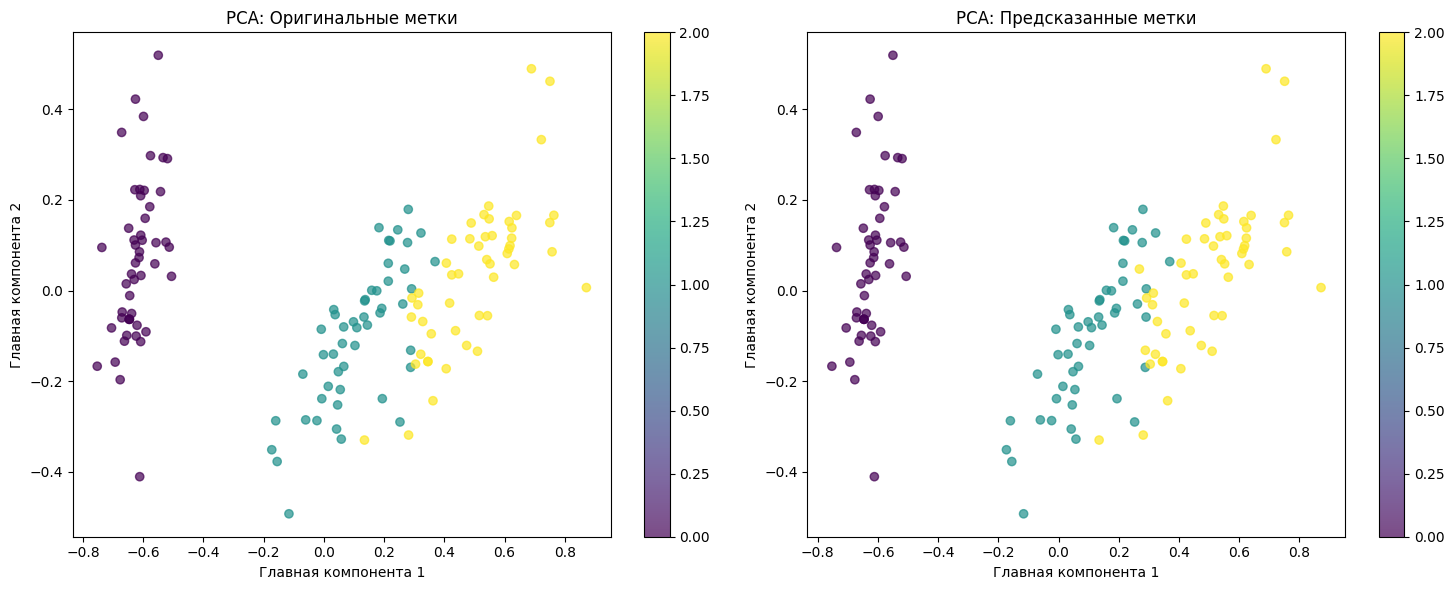

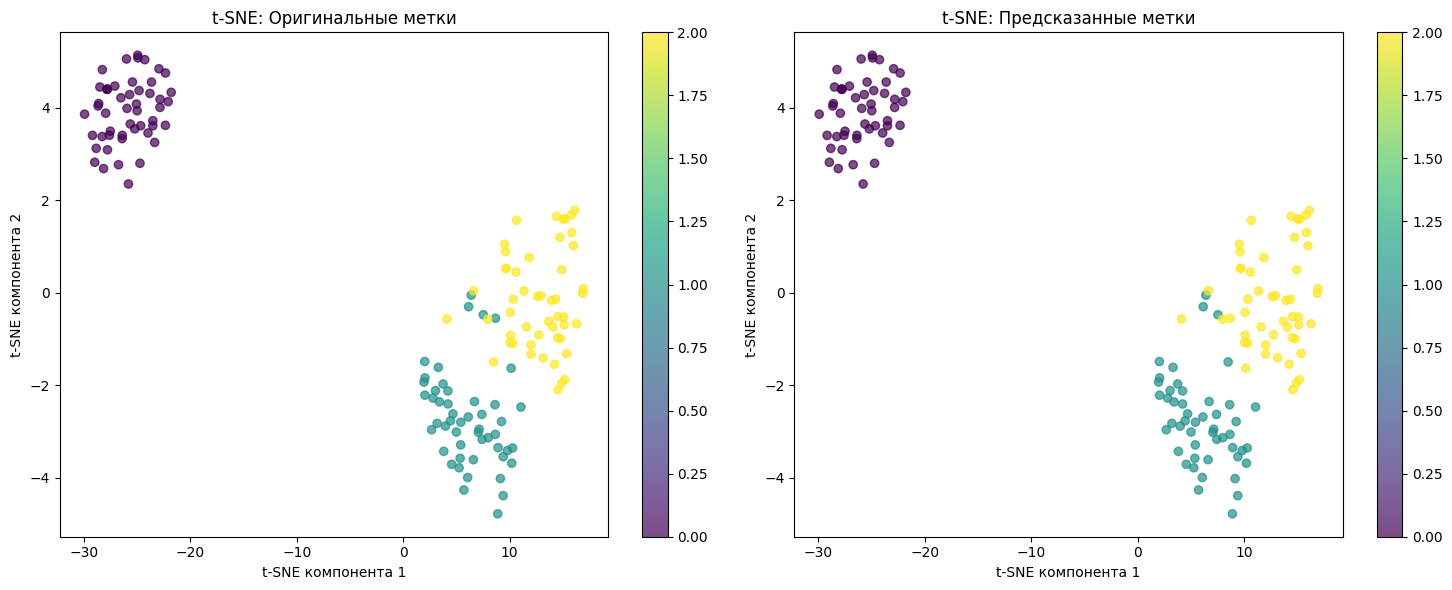

In [82]:
from sklearn.preprocessing import LabelEncoder

# Преобразуем строковые метки в числовые
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_pred_full_encoded = label_encoder.fit_transform(y_pred_full)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: PCA с предсказанными метками
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)
axes[0].set_title('PCA: Оригинальные метки')
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter1, ax=axes[0])

# График 2: PCA с предсказанными метками
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_full_encoded, cmap='viridis', alpha=0.7)
axes[1].set_title('PCA: Предсказанные метки')
axes[1].set_xlabel('Главная компонента 1')
axes[1].set_ylabel('Главная компонента 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: t-SNE с оригинальными метками
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_encoded, cmap='viridis', alpha=0.7)
axes[0].set_title('t-SNE: Оригинальные метки')
axes[0].set_xlabel('t-SNE компонента 1')
axes[0].set_ylabel('t-SNE компонента 2')
plt.colorbar(scatter1, ax=axes[0])

# График 2: t-SNE с предсказанными метками
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred_full_encoded, cmap='viridis', alpha=0.7)
axes[1].set_title('t-SNE: Предсказанные метки')
axes[1].set_xlabel('t-SNE компонента 1')
axes[1].set_ylabel('t-SNE компонента 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()